# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Helen Patricia
- **Email:** helenpatricia061006@gmail.com
- **ID Dicoding:** helenpatricia

## Menentukan Pertanyaan Bisnis

- Kategori produk mana yang memiliki penjualan rendah?
- Negara bagian mana yang memiliki aktivitas seller tertinggi?
- Bagaimana hubungan waktu pengiriman dengan skor ulasan pelanggan?
- State mana yang paling sering terlambat waktu pengirimannya?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

Pada tahap ini, dataset mentah dimuat untuk dilakukan proses assessing dan cleaning sebelum digabungkan menjadi satu data utama.

In [2]:
# Load dataset

orders = pd.read_csv("/content/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")
sellers = pd.read_csv("/content/olist_sellers_dataset.csv")
order_reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")

Dataset berhasil dimuat tanpa kendala teknis, dan seluruh tabel siap untuk dilakukan proses assessing lebih lanjut.


### Assessing Data

Tahap assessing dilakukan untuk memahami struktur data, tipe data, missing value, dan potensi duplikasi.

In [3]:
# Cek struktur dan tipe data setiap tabel

tables = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "customers": customers,
    "order_reviews": order_reviews,
    "sellers": sellers
}

for name, df in tables.items():
    print(f"\nINFO TABEL: {name}")
    df.info()
    print("-" * 60)



INFO TABEL: orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
------------------------------------------------------------

INFO TABEL: order_items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dty

In [4]:
# Cek missing value setiap tabel
for name, df in tables.items():
    print(f"\n=== MISSING VALUE: {name.upper()} ===")
    print(df.isna().sum())
    print("-" * 60)


=== MISSING VALUE: ORDERS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
------------------------------------------------------------

=== MISSING VALUE: ORDER_ITEMS ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
------------------------------------------------------------

=== MISSING VALUE: PRODUCTS ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
p

In [5]:
# Cek duplikasi data
for name, df in tables.items():
    print(f"\n=== DUPLICATED ROWS: {name.upper()} ===")
    print(df.duplicated().sum())
    print("-" * 60)


=== DUPLICATED ROWS: ORDERS ===
0
------------------------------------------------------------

=== DUPLICATED ROWS: ORDER_ITEMS ===
0
------------------------------------------------------------

=== DUPLICATED ROWS: PRODUCTS ===
0
------------------------------------------------------------

=== DUPLICATED ROWS: CUSTOMERS ===
0
------------------------------------------------------------

=== DUPLICATED ROWS: ORDER_REVIEWS ===
0
------------------------------------------------------------

=== DUPLICATED ROWS: SELLERS ===
0
------------------------------------------------------------


In [6]:
numeric_tables = {
    "order_items": order_items,
    "products": products,
    "order_reviews": order_reviews
}

for name, df in numeric_tables.items():
    print(f"\n=== DESCRIBE: {name.upper()} ===")
    print(df.describe())
    print("-" * 60)



=== DESCRIBE: ORDER_ITEMS ===
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000
------------------------------------------------------------

=== DESCRIBE: PRODUCTS ===
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean             48.476949                  771.495285            2.188986   
std              10.245741                  635.115225            1.736766   
min               5.000000                    4.000000            1.000000   
25%              42.000000     

**Insight:**
- Seluruh kolom waktu pada tabel orders, order_items, dan order_reviews masih bertipe object, sehingga perlu dikonversi ke datetime sebelum digunakan untuk analisis berbasis waktu seperti perhitungan delivery time dan keterlambatan pengiriman.

- Pada tabel orders, terdapat sekitar 3.000 data kosong pada kolom order_delivered_customer_date yang kemungkinan merepresentasikan pesanan yang dibatalkan atau belum selesai. Data ini tidak dapat digunakan untuk analisis logistik, namun tetap relevan untuk analisis lain sehingga tidak perlu dihapus.

- Pada tabel products, sekitar 610 produk tidak memiliki informasi kategori dan atribut deskriptif, sementara missing value pada dimensi fisik produk jumlahnya sangat kecil. Produk tanpa kategori akan dikecualikan hanya pada analisis berbasis kategori.

- Kolom review_score pada tabel order_reviews terisi lengkap dan dapat digunakan sebagai indikator kepuasan pelanggan. Sebaliknya, kolom komentar ulasan banyak yang kosong, yang merupakan kondisi wajar, sehingga analisis difokuskan pada skor ulasan.

- Tidak ditemukan data duplikat pada seluruh tabel utama, menunjukkan integritas data yang baik. Selain itu, jumlah baris pada order_items lebih besar dibandingkan orders, menandakan relasi one-to-many yang perlu diperhatikan saat melakukan agregasi jumlah pesanan dan nilai transaksi.

- Berdasarkan statistik deskriptif awal, harga produk dan biaya pengiriman memiliki variasi yang cukup besar. Rata-rata skor ulasan pelanggan sebesar 4.09 menunjukkan tingkat kepuasan yang relatif tinggi, meskipun masih terdapat sebagian ulasan rendah yang perlu dianalisis lebih lanjut.

### Cleaning Data

Proses cleaning difokuskan pada konversi kolom waktu dan pembuatan fitur logistik yang akan digunakan dalam analisis selanjutnya.

#### Konversi kolom waktu ke datetime

In [7]:
# Konversi kolom waktu pada tabel orders
date_cols_orders = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

#### Subset untuk Analisis Delivery Time

In [8]:
# Subset orders yang valid untuk analisis delivery time
orders_delivery = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

Setelah proses cleaning selesai, seluruh dataset digabungkan dan disimpan sebagai satu data utama (`main_data.csv`) yang akan digunakan pada seluruh proses analisis dan dashboard.

In [9]:
df = orders.merge(order_items, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
df = df.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
df = df.merge(order_reviews[["order_id", "review_score"]], on="order_id", how="left")

In [10]:
# Hitung delivery time (hari)
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

# Flag keterlambatan pengiriman
df["is_delayed"] = (
    df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]
)

In [11]:
main_data = df[[
    "order_id",
    "customer_unique_id",
    "customer_state",
    "seller_state",
    "product_category_name",
    "order_purchase_timestamp",
    "delivery_time",
    "is_delayed",
    "price",
    "review_score"
]]

main_data.to_csv("main_data.csv", index=False)

In [12]:
df = pd.read_csv(
    "main_data.csv",
    parse_dates=["order_purchase_timestamp"]
)

**Insight:**
- Setelah dilakukan konversi kolom waktu pada tabel `orders`, data siap digunakan untuk analisis berbasis waktu seperti perhitungan durasi pengiriman dan identifikasi keterlambatan pengiriman.

- Data pesanan yang belum memiliki tanggal pengiriman tidak dihapus secara global, namun secara implisit tidak memengaruhi analisis logistik karena nilai `delivery_time` dan `is_delayed` hanya relevan untuk pesanan yang telah dikirim.

- Proses penggabungan seluruh dataset menghasilkan satu data utama (`main_data.csv`) yang merepresentasikan data transaksi secara komprehensif dan konsisten, sehingga dapat digunakan sebagai satu-satunya sumber data untuk analisis lanjutan dan dashboard.

## Exploratory Data Analysis (EDA)

### Explore Product Categories with Low Sales

In [13]:
# Mengurutkan kategori berdasarkan volume penjualan terendah
low_sales_categories = (
    df.groupby("product_category_name")
    .size()
    .reset_index(name="total_sales")
    .sort_values("total_sales")
    .head(10)
)

low_sales_categories

,product_category_name,total_sales
67,seguros_e_servicos,2
37,fashion_roupa_infanto_juvenil,8
60,pc_gamer,9
17,cds_dvds_musicais,14
46,la_cuisine,14
65,portateis_cozinha_e_preparadores_de_alimentos,15
4,artes_e_artesanato,24
15,casa_conforto_2,30
35,fashion_esporte,31
41,flores,33


### Explore States with the Highest Number of Sellers

In [14]:
seller_activity = (
    df.groupby("seller_state")
    .size()
    .reset_index(name="total_seller_activity")
    .sort_values("total_seller_activity", ascending=False)
    .head(10)
)

seller_activity

,seller_state,total_seller_activity
22,SP,80834
8,MG,8874
15,PR,8748
16,RJ,4835
20,SC,4089
19,RS,2210
4,DF,901
2,BA,645
6,GO,521
13,PE,448


### Explore the Relationship Between Delivery Time and Review Scores

In [15]:
# Rata-rata review score berdasarkan keterlambatan
delay_review_summary = (
    df.groupby("is_delayed")["review_score"]
    .mean()
    .reset_index()
)

delay_review_summary["status"] = delay_review_summary["is_delayed"].map(
    {False: "Tepat Waktu", True: "Terlambat"}
)

delay_review_summary

,is_delayed,review_score,status
0,False,4.137190,Tepat Waktu
1,True,2.548884,Terlambat


### Explore States with the Highest Delivery Delay Frequency

In [16]:
# Menghitung jumlah total order dan jumlah order terlambat per state
state_delay = (
    df.groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        delayed_orders=("is_delayed", "sum")
    )
    .reset_index()
)

# Menghitung rasio keterlambatan
state_delay["delay_ratio"] = (
    state_delay["delayed_orders"] / state_delay["total_orders"]
)

In [17]:
# Memilih state dengan jumlah order terbesar agar hasil lebih stabil
top_states_delay = (
    state_delay
    .sort_values("total_orders", ascending=False)
    .head(10)
    .sort_values("delay_ratio", ascending=False)
)

top_states_delay

,customer_state,total_orders,delayed_orders,delay_ratio
4,BA,3380,508,0.150296
18,RJ,12852,1846,0.143635
7,ES,2033,273,0.134284
23,SC,3637,396,0.108881
8,GO,2020,181,0.089604
6,DF,2140,178,0.083178
22,RS,5466,426,0.077936
25,SP,41746,2685,0.064318
10,MG,11635,707,0.060765
17,PR,5045,272,0.053915


**Insight:**
- Beberapa kategori produk seperti *seguros_e_servicos*, *fashion_roupa_infanto_juvenil*, dan *pc_gamer* memiliki volume penjualan yang jauh lebih rendah dibandingkan kategori lainnya. Hal ini menunjukkan bahwa permintaan pelanggan terhadap kategori-kategori tersebut relatif kecil, sehingga kontribusinya terhadap total transaksi platform juga terbatas.

- Aktivitas seller sangat terkonsentrasi pada beberapa negara bagian tertentu. State SP (São Paulo) menunjukkan jumlah aktivitas seller yang paling tinggi dibandingkan state lainnya. Pola ini mengindikasikan adanya sentralisasi penjual dan aktivitas ekonomi pada wilayah tertentu, sementara banyak state lain memiliki tingkat aktivitas seller yang relatif rendah.

- Terdapat perbedaan yang jelas pada rata-rata skor ulasan antara pesanan yang dikirim tepat waktu dan yang mengalami keterlambatan. Pesanan yang dikirim tepat waktu cenderung memperoleh skor ulasan yang lebih tinggi, sementara keterlambatan pengiriman berkorelasi dengan penurunan tingkat kepuasan pelanggan.

- Rasio keterlambatan pengiriman bervariasi antar negara bagian. Beberapa state seperti BA (Bahia), RJ (Rio de Janeiro), dan ES (Espírito Santo) menunjukkan rasio keterlambatan yang lebih tinggi dibandingkan state lain dengan volume pesanan besar. Hal ini mengindikasikan adanya perbedaan performa logistik antar wilayah.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk mana yang memiliki penjualan rendah?


In [18]:
min_value = low_sales_categories["total_sales"].min()

In [19]:
colors = [
    "#D62728" if val == min_value else "#B0B0B0"
    for val in low_sales_categories["total_sales"]
]

/tmp/ipython-input-748912876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


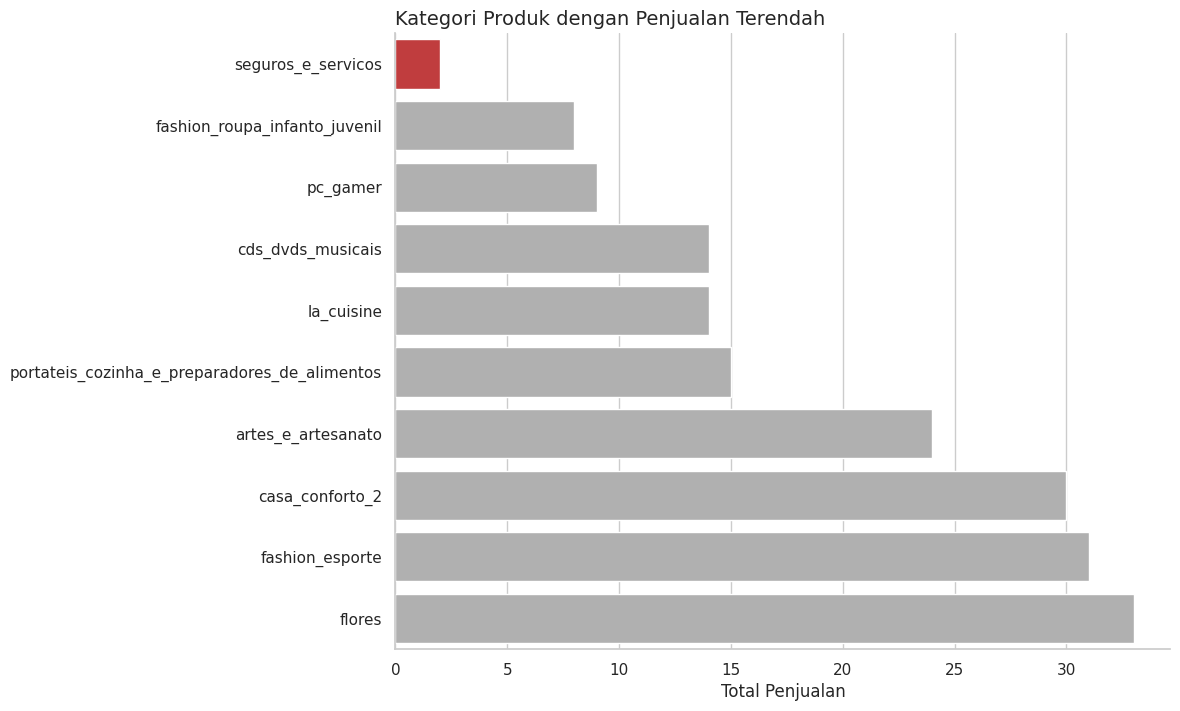

In [20]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=low_sales_categories,
    x="total_sales",
    y="product_category_name",
    palette=colors
)

plt.title("Kategori Produk dengan Penjualan Terendah", loc="left", fontsize=14)
plt.xlabel("Total Penjualan")
plt.ylabel(None)
sns.despine()
plt.show()

### Pertanyaan 2: Negara bagian mana yang memiliki jumlah pelanggan, seller, dan nilai transaksi tertinggi?

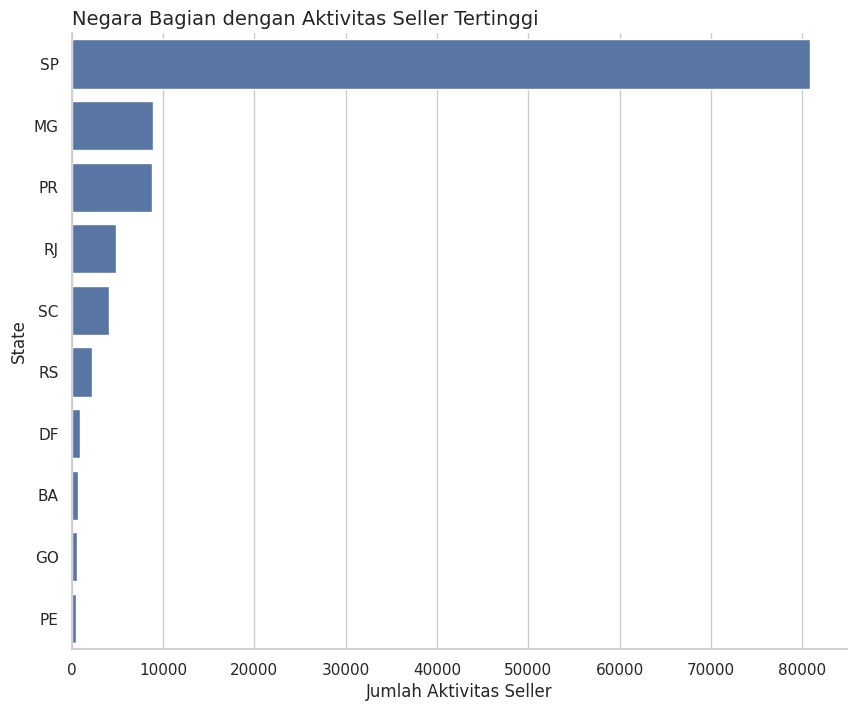

In [21]:
# Visualisasi jumlah seller per state
plt.figure(figsize=(10, 8))
sns.barplot(
    data=seller_activity,
    x="total_seller_activity",
    y="seller_state",
    color='#4C72B0'
)
plt.title("Negara Bagian dengan Aktivitas Seller Tertinggi", loc="left", fontsize=14)
plt.xlabel("Jumlah Aktivitas Seller")
plt.ylabel("State")
sns.despine()
plt.show()

### Pertanyaan 3: Bagaimana hubungan waktu pengiriman dengan skor ulasan pelanggan?

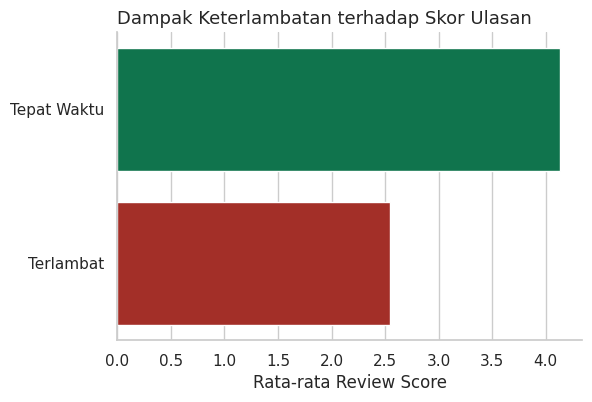

In [22]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=delay_review_summary,
    x="review_score",
    y="status",
    hue="status",
    palette=["#008450", "#B81D13"],
    legend=False
)
plt.title("Dampak Keterlambatan terhadap Skor Ulasan", loc="left", fontsize=13)
plt.xlabel("Rata-rata Review Score")
plt.ylabel(None)
sns.despine()
plt.show()

### Pertanyaan 4: Apakah waktu pengiriman berbeda antar negara bagian, dan state mana yang paling sering terlambat?

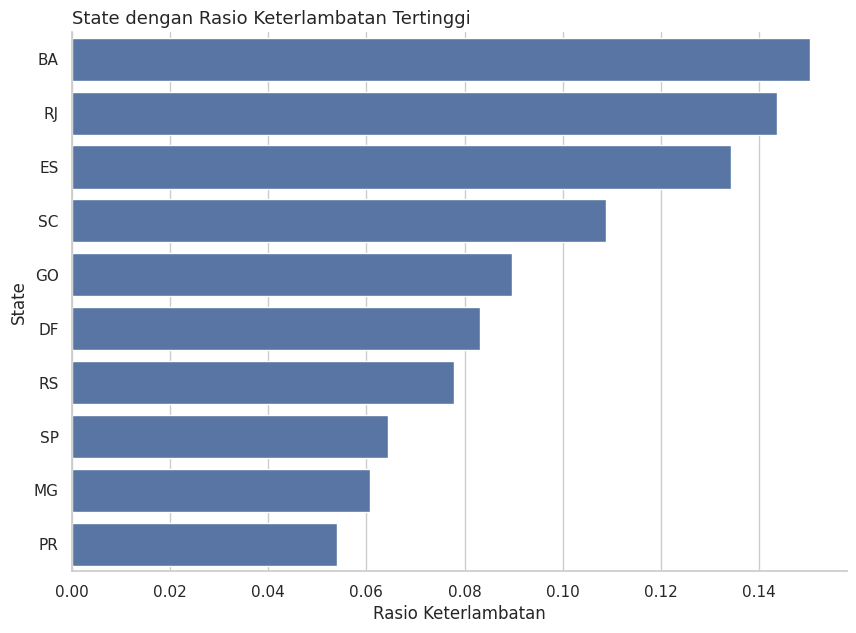

In [23]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_states_delay,
    x="delay_ratio",
    y="customer_state",
    color='#4C72B0'
)
plt.title("State dengan Rasio Keterlambatan Tertinggi", loc="left", fontsize=13)
plt.xlabel("Rasio Keterlambatan")
plt.ylabel("State")
sns.despine()
plt.show()

## Analisis Lanjutan (Opsional)

In [24]:
# Merge dataset utama
df = orders.merge(order_items, on='order_id')
df = df.merge(customers, on='customer_id')

RFM Analysis

In [25]:
# Nilai recency dihitung dari selisih hari transaksi terakhir, frequency dari jumlah transaksi unik, dan monetary dari total nilai pembelian pelanggan.
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_unique_id")
    .agg(
        recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("price", "sum")
    )
    .reset_index()
)

In [26]:
# Nilai RFM dibagi ke dalam beberapa kelompok menggunakan teknik binning untuk mempermudah interpretasi hasil analisis dan menghindari duplikasi batas kuartil.
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1])
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4])
rfm["F_score"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 5, rfm["frequency"].max()],
    labels=[1, 2, 3, 4])

In [27]:
# Pelanggan dikelompokkan menjadi loyal, regular, dan at risk customer menggunakan aturan berbasis bisnis.
def rfm_segment(row):
    if row["R_score"] == 4 and row["F_score"] == 4:
        return "Loyal Customer"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk Customer"
    else:
        return "Regular Customer"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)
rfm["segment"].value_counts()

,count
segment,
Regular Customer,95326
At Risk Customer,89
Loyal Customer,5


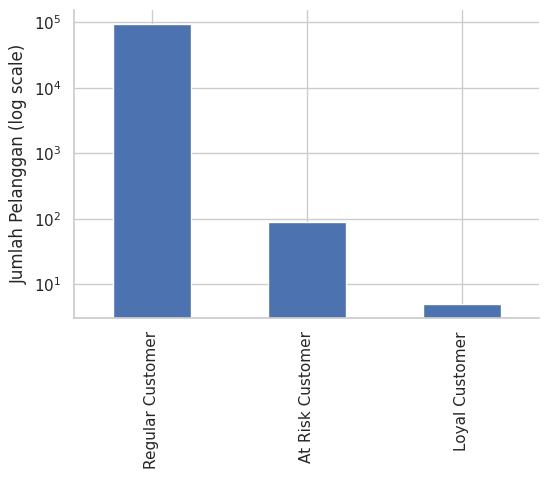

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
rfm["segment"].value_counts().plot(kind="bar", ax=ax)
ax.set_yscale("log")
ax.set_xlabel(None)
ax.set_ylabel("Jumlah Pelanggan (log scale)")
sns.despine()
plt.show()

**Insight:**
- Hasil segmentasi RFM menunjukkan bahwa mayoritas pelanggan termasuk dalam kategori *Regular Customer*, sementara jumlah *Loyal Customer* sangat kecil dan *At Risk Customer* hanya sebagian kecil dari total pelanggan. Distribusi ini mencerminkan rendahnya tingkat pembelian ulang dan loyalitas pelanggan, sehingga masih terdapat peluang besar untuk meningkatkan strategi retensi.

- Distribusi segment pelanggan sangat tidak seimbang, sehingga visualisasi menggunakan skala logaritmik diperlukan agar seluruh segment tetap terlihat secara proporsional.

Clustering Tanpa Machine Learning

In [29]:
# Manual Grouping (Aturan Bisnis), pelanggan dikelompokkan berdasarkan total pengeluaran ke dalam kategori high, medium, dan low value.
def spending_category(x):
    if x >= 500:
        return "High Value"
    elif x >= 200:
        return "Medium Value"
    else:
        return "Low Value"

rfm["spending_category"] = rfm["monetary"].apply(spending_category)

In [30]:
# Binning Frequency Transaksi, frekuensi transaksi dibagi ke dalam beberapa interval menggunakan teknik binning untuk melihat tingkat aktivitas pelanggan.
rfm["frequency_bin"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 3, 5, rfm["frequency"].max()],
    labels=["Very Low", "Low", "Medium", "High"]
)

<Axes: title={'center': 'Distribusi Kategori Pelanggan'}, ylabel='count'>

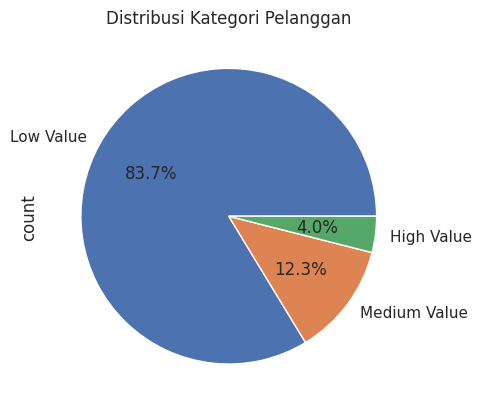

In [31]:
# Visualisasi digunakan untuk menampilkan proporsi setiap kategori pelanggan secara ringkas dan informatif.
rfm['spending_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribusi Kategori Pelanggan'
)

Berdasarkan pengelompokan manual terhadap total pengeluaran pelanggan, sebagian besar pelanggan termasuk dalam kategori *Low Value*, diikuti oleh *Medium Value*, dan hanya sebagian kecil yang tergolong *High Value*. Hal ini menunjukkan bahwa sebagian besar transaksi memiliki nilai pembelian relatif rendah, sementara kontribusi pendapatan terbesar kemungkinan berasal dari kelompok pelanggan bernilai tinggi yang jumlahnya terbatas.

## Conclusion

Secara keseluruhan, analisis menunjukkan bahwa performa logistik, khususnya ketepatan waktu pengiriman, memiliki peran penting dalam memengaruhi kepuasan pelanggan. Selain itu, distribusi penjualan produk dan aktivitas seller yang tidak merata antar wilayah mengindikasikan adanya peluang optimasi dari sisi operasional dan strategi bisnis.

Segmentasi pelanggan melalui RFM Analysis memperlihatkan bahwa tingkat loyalitas pelanggan masih relatif rendah, sehingga platform memiliki ruang besar untuk meningkatkan pembelian ulang dan retensi pelanggan. Pendekatan berbasis data seperti ini memungkinkan pengambilan keputusan yang lebih terarah untuk meningkatkan kualitas layanan, efisiensi operasional, dan pengalaman pelanggan secara keseluruhan.